# Proyecto Integrador — Regresión Lineal: Concentración de CO (Salt Lake City, 2022)

Este notebook analiza datos de calidad del aire para predecir la **concentración máxima diaria de CO (8 horas)** mediante un modelo de regresión lineal múltiple.

## 1. Importación de librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline

## 2. Carga y exploración de datos (EDA)

In [ ]:
file = '/content/Archivos_Data/Salt_Lake_UT_2022.csv'
df1 = pd.read_csv(file)
df1.head()

,Date,Source,Site ID,POC,Daily Max 8-hour CO Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,490352005,1,0.4,ppm,5,Copper View,19,79.0,...,Carbon monoxide,93,41620,"Salt Lake City, UT",49,Utah,35,Salt Lake,40.598056,-111.894167
1,01/02/2022,AQS,490352005,1,0.6,ppm,7,Copper View,24,100.0,...,Carbon monoxide,93,41620,"Salt Lake City, UT",49,Utah,35,Salt Lake,40.598056,-111.894167
2,01/03/2022,AQS,490352005,1,0.8,ppm,9,Copper View,24,100.0,...,Carbon monoxide,93,41620,"Salt Lake City, UT",49,Utah,35,Salt Lake,40.598056,-111.894167
3,01/04/2022,AQS,490352005,1,0.4,ppm,5,Copper View,24,100.0,...,Carbon monoxide,93,41620,"Salt Lake City, UT",49,Utah,35,Salt Lake,40.598056,-111.894167
4,01/05/2022,AQS,490352005,1,0.5,ppm,6,Copper View,24,100.0,...,Carbon monoxide,93,41620,"Salt Lake City, UT",49,Utah,35,Salt Lake,40.598056,-111.894167


# Consultar información básica sobre el conjunto de datos
El método 'info()'los tipos y números de datos

In [ ]:
df1.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               365 non-null    object 
 1   Source                             365 non-null    object 
 2   Site ID                            365 non-null    int64  
 3   POC                                365 non-null    int64  
 4   Daily Max 8-hour CO Concentration  365 non-null    float64
 5   Units                              365 non-null    object 
 6   Daily AQI Value                    365 non-null    int64  
 7   Local Site Name                    365 non-null    object 
 8   Daily Obs Count                    365 non-null    int64  
 9   Percent Complete                   365 non-null    float64
 10  AQS Parameter Code                 365 non-null    int64  
 11  AQS Parameter Description          365 non-null    object 

El método 'describe()' obtiene un resumen de estadísticas de las características del conjunto de datos

In [ ]:
df1.describe().round(1)

,Site ID,POC,Daily Max 8-hour CO Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
count,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0,365.0
mean,490352005.0,1.0,0.3,3.2,23.9,99.4,42101.0,93.0,41620.0,49.0,35.0,40.6,-111.9
std,0.0,0.0,0.2,2.8,0.9,3.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,490352005.0,1.0,0.0,0.0,14.0,58.0,42101.0,93.0,41620.0,49.0,35.0,40.6,-111.9
25%,490352005.0,1.0,0.1,1.0,24.0,100.0,42101.0,93.0,41620.0,49.0,35.0,40.6,-111.9
50%,490352005.0,1.0,0.2,2.0,24.0,100.0,42101.0,93.0,41620.0,49.0,35.0,40.6,-111.9
75%,490352005.0,1.0,0.4,5.0,24.0,100.0,42101.0,93.0,41620.0,49.0,35.0,40.6,-111.9
max,490352005.0,1.0,1.0,11.0,24.0,100.0,42101.0,93.0,41620.0,49.0,35.0,40.6,-111.9


**El método 'columns' obtiene los nombres de las columnas (características)**


In [ ]:
df1.columns

Index(['Date', 'Source', 'Site ID', 'POC', 'Daily Max 8-hour CO Concentration',
       'Units', 'Daily AQI Value', 'Local Site Name', 'Daily Obs Count',
       'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description',
       'Method Code', 'CBSA Code', 'CBSA Name', 'State FIPS Code', 'State',
       'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude'],
      dtype='object')

# Visualización básica del conjunto de datos
Pairplots usando seaborn

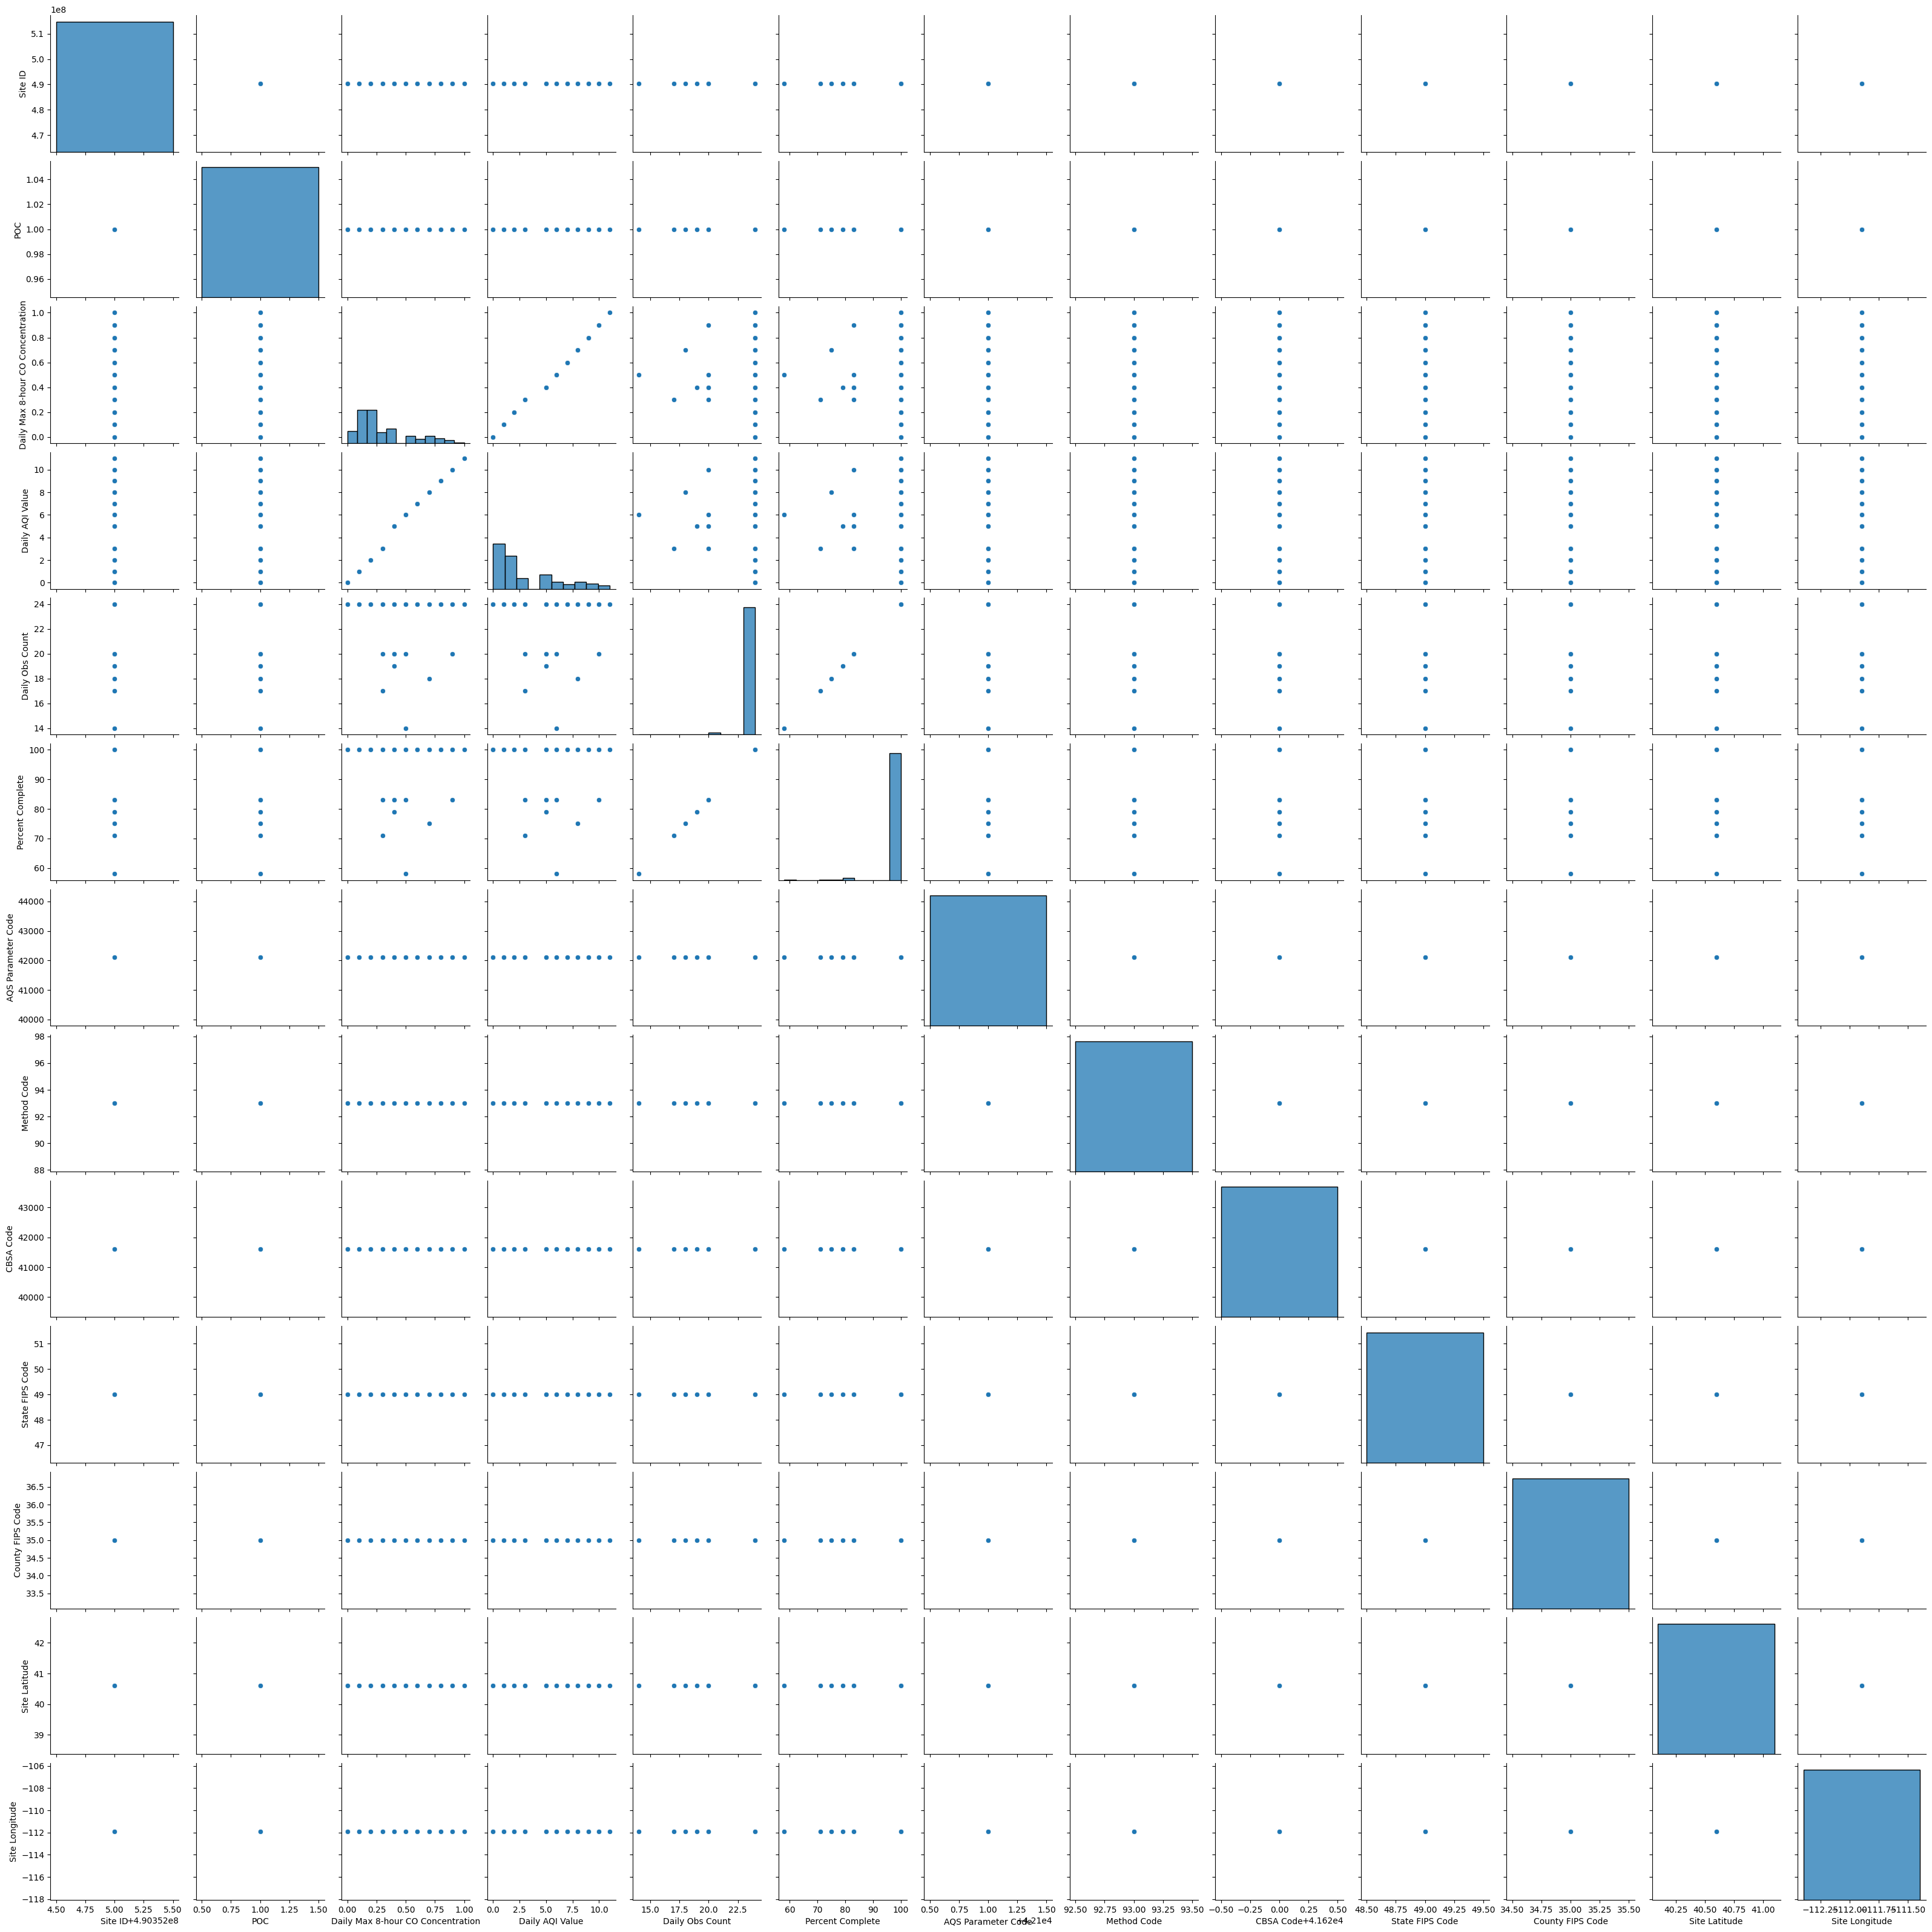

In [ ]:
sns.pairplot(df1)

### Distribución de la variable objetivo

<Axes: ylabel='Frequency'>

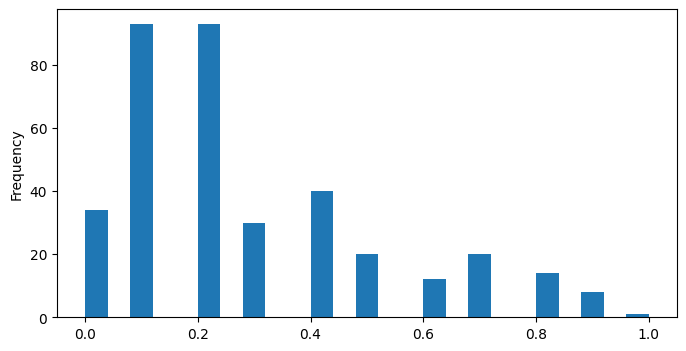

In [ ]:
#Max daily 8 hour CO concentration
df1['Daily Max 8-hour CO Concentration'].plot.hist(bins=25, figsize=(8,4))

<Axes: ylabel='Density'>

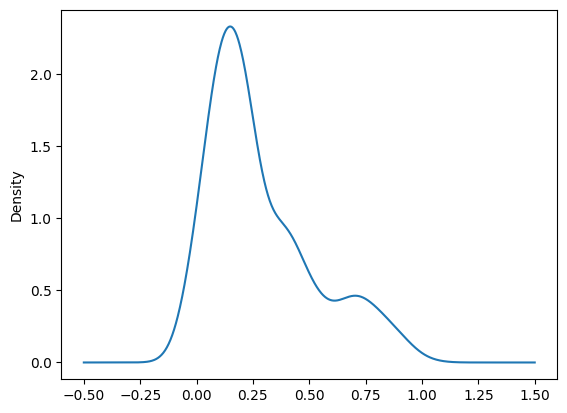

In [ ]:
df1['Daily Max 8-hour CO Concentration'].plot.density()

### Matriz de correlación

In [ ]:
numeric_df = df1.select_dtypes(include=[np.number])
numeric_df.corr()

,Site ID,POC,Daily Max 8-hour CO Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,State FIPS Code,County FIPS Code,Site Latitude,Site Longitude
Site ID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
POC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily Max 8-hour CO Concentration,NaN,NaN,1.000000,0.996201,-0.128755,-0.129156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily AQI Value,NaN,NaN,0.996201,1.000000,-0.134350,-0.134819,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Daily Obs Count,NaN,NaN,-0.128755,-0.134350,1.000000,0.999960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Percent Complete,NaN,NaN,-0.129156,-0.134819,0.999960,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AQS Parameter Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Method Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CBSA Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State FIPS Code,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

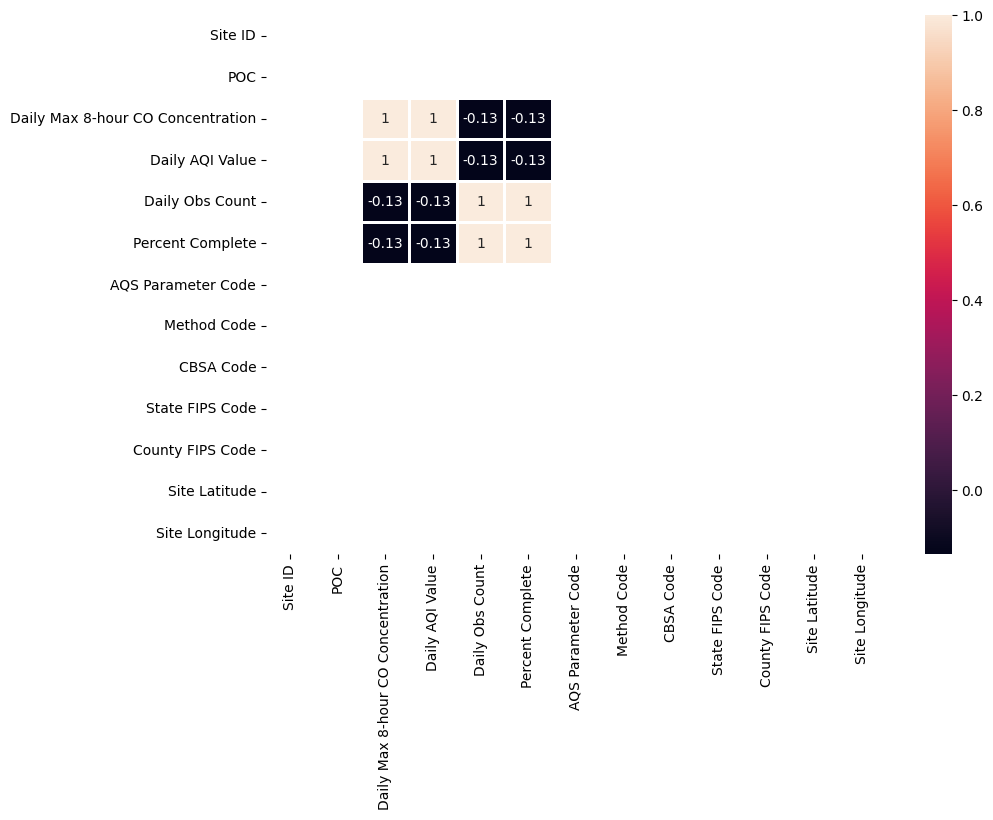

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, linewidths=2)

## 3. Preparación de variables (X, y)

Se excluyen columnas de texto, IDs y códigos que no aportan a la regresión, y se separa la variable objetivo.

In [ ]:
variable_objetivo = 'Daily Max 8-hour CO Concentration'

columnas_a_excluir = [
    'Date',
    'Source',
    'Site ID',
    'POC',
    'Units',
    'Local Site Name',
    'AQS Parameter Code',
    'AQS Parameter Description',
    'Method Code',
    'CBSA Code',
    'CBSA Name',
    'State FIPS Code',
    'State',
    'County FIPS Code',
    'County',
    variable_objetivo,  # quitamos la variable objetivo de las X
]

y = df1[variable_objetivo]
X = df1.drop(columns=[c for c in columnas_a_excluir if c in df1.columns])
X = X.select_dtypes(include=['number'])  # solo columnas numéricas

print('Tamaño de Características:', X.shape)
print('Tamaño de Variable Objetivo:', y.shape)
X.head()

Tamaño de Características: (365, 5)
Tamaño de Variable Objetivo: (365,)


,Daily AQI Value,Daily Obs Count,Percent Complete,Site Latitude,Site Longitude
0,5,19,79.0,40.598056,-111.894167
1,7,24,100.0,40.598056,-111.894167
2,9,24,100.0,40.598056,-111.894167
3,5,24,100.0,40.598056,-111.894167
4,6,24,100.0,40.598056,-111.894167


## 4. División en conjuntos de entrenamiento y prueba

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

print('Tamaño del conjunto de características de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de características de prueba:', X_test.shape)
print('Tamaño de la variable objetivo de entrenamiento:', y_train.shape)
print('Tamaño de la variable objetivo de prueba:', y_test.shape)

Tamaño del conjunto de características de entrenamiento: (255, 5)
Tamaño del conjunto de características de prueba: (110, 5)
Tamaño de la variable objetivo de entrenamiento: (255,)
Tamaño de la variable objetivo de prueba: (110,)


## 5. Entrenamiento del modelo de Regresión Lineal

In [ ]:
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

## 6. Resultados del modelo

In [ ]:
print('El término de intersección del modelo lineal:', lm.intercept_)
print('Los coeficientes del modelo lineal:', lm.coef_)

El término de intersección del modelo lineal: -0.05103187366620926
Los coeficientes del modelo lineal: [ 8.51918713e-02  2.57342336e-01 -6.10906643e-02 -5.35733454e-28
 -1.17407171e-27]


In [ ]:
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=['Coefficients'])
cdf

,Coefficients
Daily AQI Value,8.519187e-02
Daily Obs Count,2.573423e-01
Percent Complete,-6.109066e-02
Site Latitude,-5.357335e-28
Site Longitude,-1.174072e-27


In [ ]:
train_pred = lm.predict(X_train)
test_pred = lm.predict(X_test)

### Significancia estadística de los coeficientes (t-statistic)

In [ ]:
n = X_train.shape[0]
k = X_train.shape[1]
dfN = n - k

train_error = np.square(train_pred - y_train)
sum_error = np.sum(train_error)

se = [0] * k
for i in range(k):
    r = sum_error / dfN
    r = r / np.sum(
        np.square(
            X_train[list(X_train.columns)[i]]
            - X_train[list(X_train.columns)[i]].mean()
        )
    )
    se[i] = np.sqrt(r)

cdf['Standard Error'] = se
cdf['t-statistic'] = cdf['Coefficients'] / cdf['Standard Error']
cdf

,Coefficients,Standard Error,t-statistic
Daily AQI Value,8.519187e-02,4.505966e-04,1.890646e+02
Daily Obs Count,2.573423e-01,2.252417e-03,1.142517e+02
Percent Complete,-6.109066e-02,5.369459e-04,-1.137743e+02
Site Latitude,-5.357335e-28,1.731933e+11,-3.093269e-39
Site Longitude,-1.174072e-27,8.659666e+10,-1.355793e-38


In [ ]:
print('Por lo tanto, las características organizadas en orden de importancia \n', '-'*90, sep='')
l = list(cdf.sort_values('t-statistic', ascending=False).index)
print(' > \n'.join(l))

Por lo tanto, las características organizadas en orden de importancia 
------------------------------------------------------------------------------------------
Daily AQI Value > 
Daily Obs Count > 
Site Latitude > 
Site Longitude > 
Percent Complete


### Relación de las 4 variables más importantes con la variable objetivo

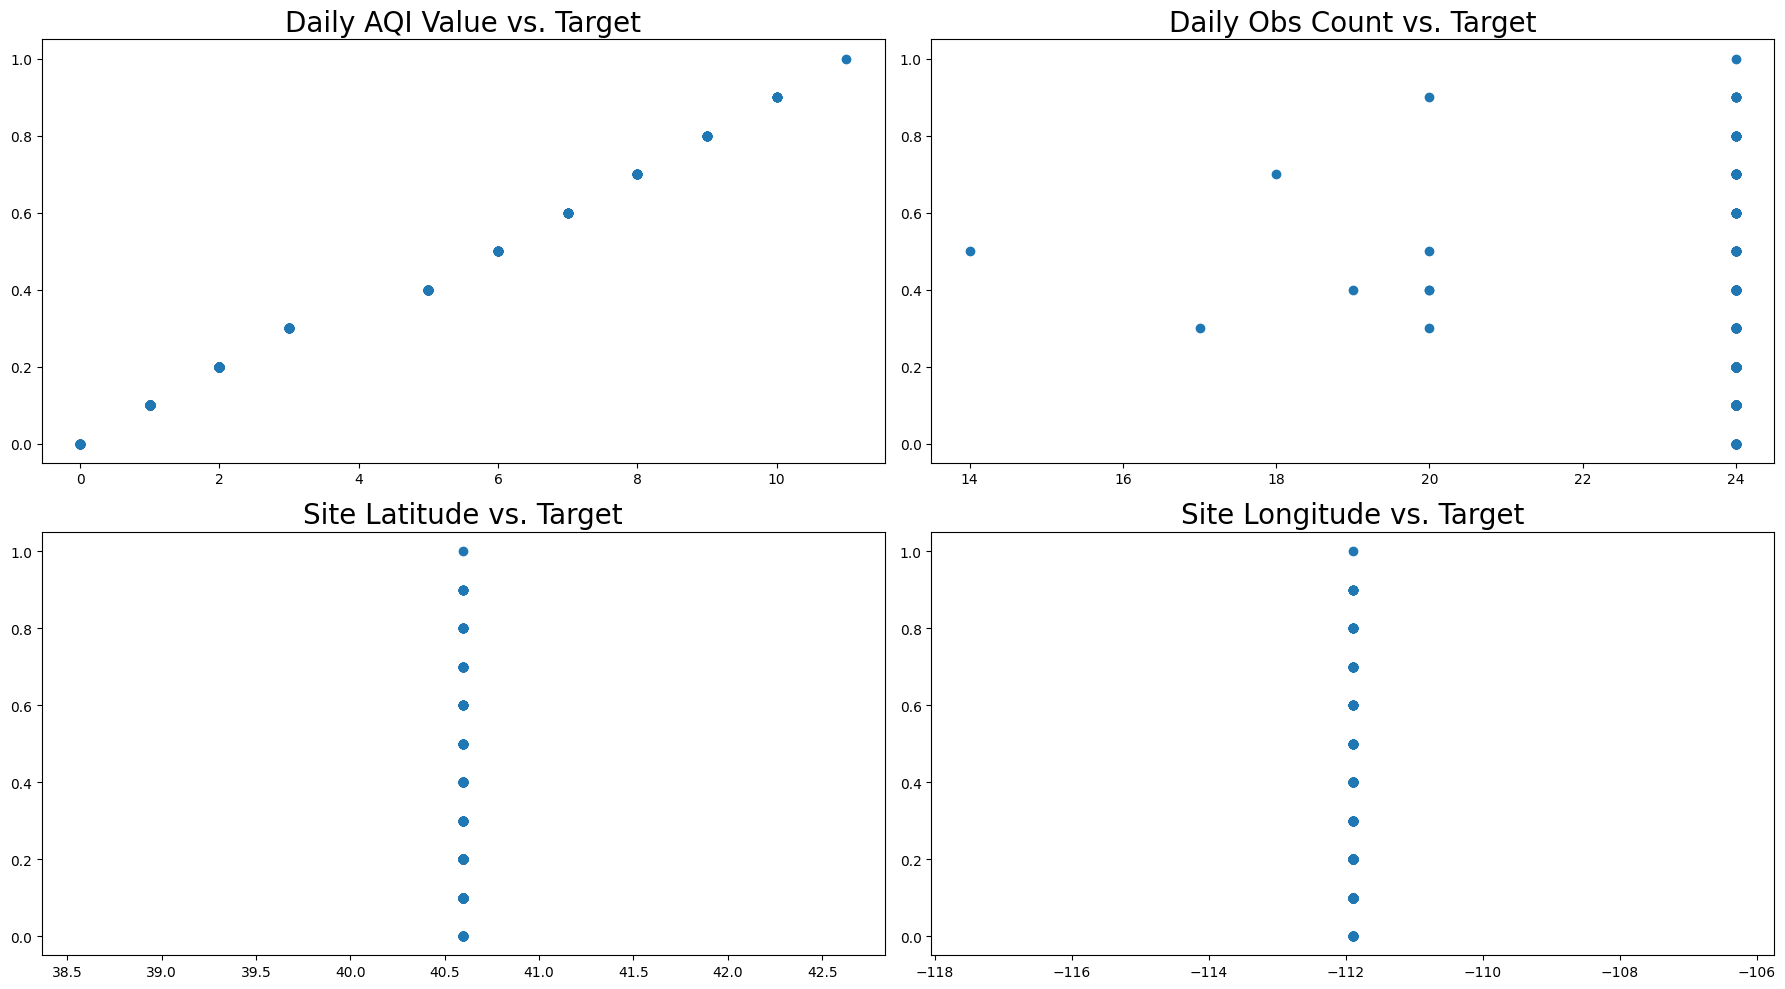

In [ ]:
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 2)

ax0 = plt.subplot(gs[0])
ax0.scatter(df1[l[0]], df1[variable_objetivo])
ax0.set_title(l[0] + ' vs. Target', fontdict={'fontsize': 20})

ax1 = plt.subplot(gs[1])
ax1.scatter(df1[l[1]], df1[variable_objetivo])
ax1.set_title(l[1] + ' vs. Target', fontdict={'fontsize': 20})

ax2 = plt.subplot(gs[2])
ax2.scatter(df1[l[2]], df1[variable_objetivo])
ax2.set_title(l[2] + ' vs. Target', fontdict={'fontsize': 20})

ax3 = plt.subplot(gs[3])
ax3.scatter(df1[l[3]], df1[variable_objetivo])
ax3.set_title(l[3] + ' vs. Target', fontdict={'fontsize': 20})

plt.tight_layout()
plt.show()


R cuadrado del ajuste del modelo

In [ ]:
print('Valor del R cuadrado de este ajuste (entrenamiento):', round(metrics.r2_score(y_train, train_pred), 3))

Valor del R cuadrado de este ajuste (entrenamiento): 0.993


## 7. Evaluación del modelo con datos de prueba

In [ ]:
predictions = lm.predict(X_test)
print('Tipo del objeto predicho :', type(predictions))
print('Tamaño del objeto predicho:', predictions.shape)

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho: (110,)


### Valores reales vs. predichos

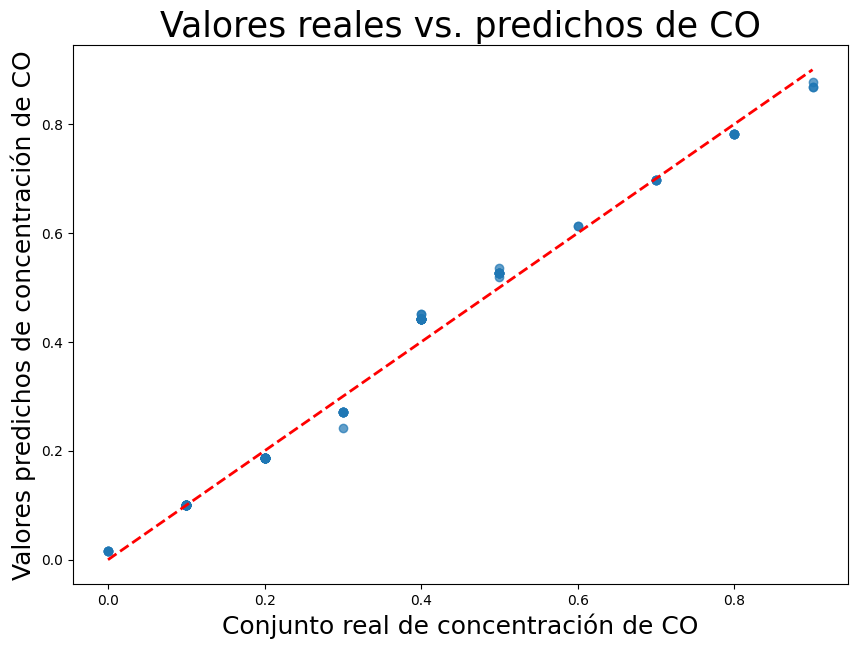

In [ ]:
plt.figure(figsize=(10, 7))
plt.title('Valores reales vs. predichos de CO', fontsize=25)
plt.xlabel('Conjunto real de concentración de CO', fontsize=18)
plt.ylabel('Valores predichos de concentración de CO', fontsize=18)
plt.scatter(x=y_test, y=predictions, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--',
    lw=2,
)
plt.show()

### Análisis de residuos

Visualizamos el histograma de los residuos, es decir, errores predichos (se espera un patrón distribuido normalmente)

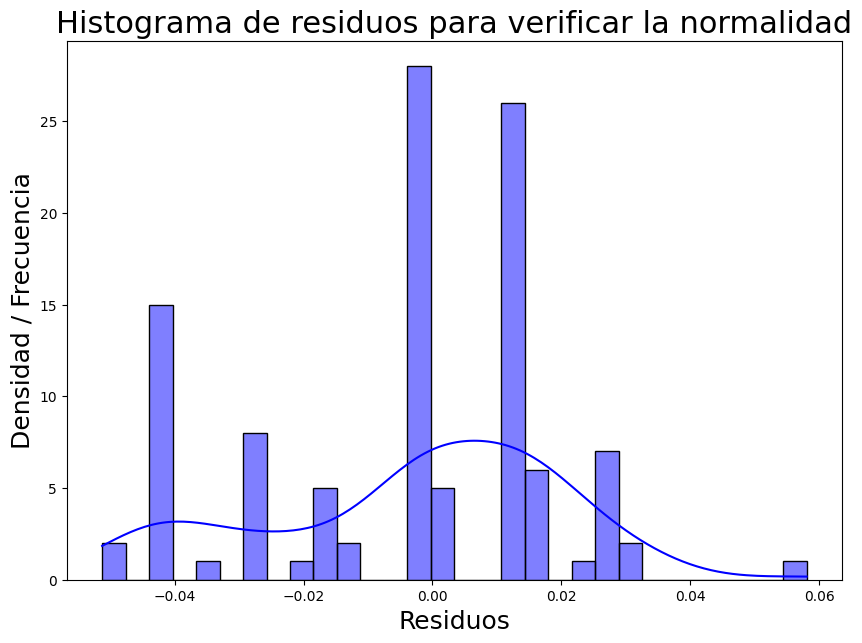

In [ ]:
residuos = y_test - predictions

plt.figure(figsize=(10, 7))
plt.title('Histograma de residuos para verificar la normalidad', fontsize=22)
plt.xlabel('Residuos', fontsize=18)
plt.ylabel('Densidad / Frecuencia', fontsize=18)
sns.histplot(residuos, kde=True, color='blue', bins=30)
plt.show()

Diagrama de dispersión de residuos y valores predichos (Homoscedasticidad)

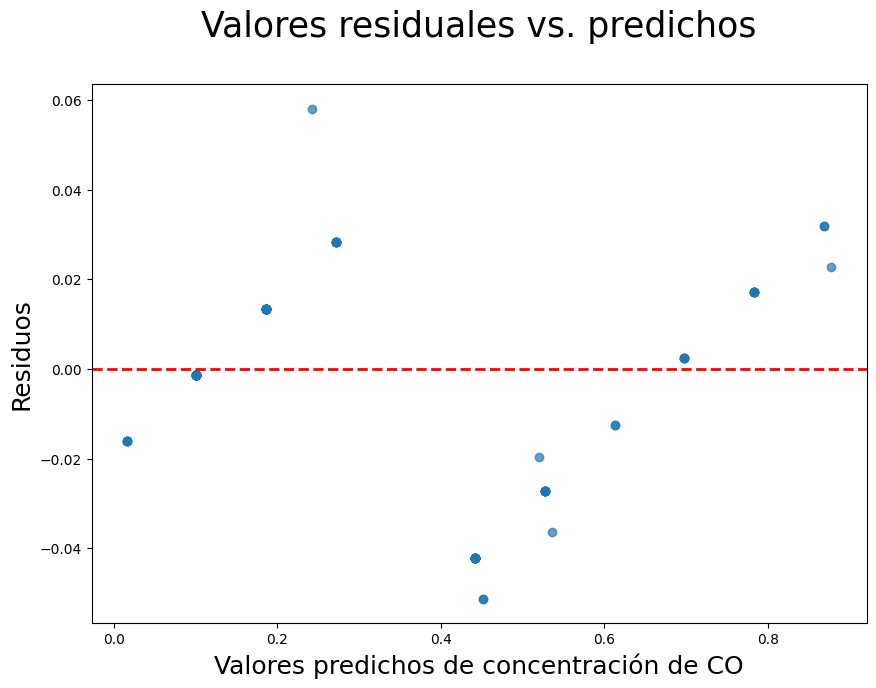

In [ ]:
plt.figure(figsize=(10, 7))
plt.title('Valores residuales vs. predichos\n', fontsize=25)
plt.xlabel('Valores predichos de concentración de CO', fontsize=18)
plt.ylabel('Residuos', fontsize=18)
plt.scatter(x=predictions, y=residuos, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.show()

## 8. Métricas finales del modelo

In [ ]:
print('Mean absolute error (MAE):', metrics.mean_absolute_error(y_test, predictions))
print('Mean square error (MSE):', metrics.mean_squared_error(y_test, predictions))
print('Root mean square error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('Valor R-squared de las predicciones:', round(metrics.r2_score(y_test, predictions), 3))

Mean absolute error (MAE): 0.017805905982319636
Mean square error (MSE): 0.0005382335231340192
Root mean square error (RMSE): 0.023199860411951174
Valor R-squared de las predicciones: 0.99


In [ ]:
# Importamos las librerías necesarias para el análisis, manipulación y visualización
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd

# Importar el método make_regression por si requieres generar muestras de datos artificiales
from sklearn.datasets import make_regression

In [ ]:
# Definimos los parámetros para la generación de datos artificiales de regresión.
n_samples = 100 # Número de muestras
n_features = 6 # Número de características
n_informative = 3 # Número de características informativas i.e. características reales que influyen en la salida

In [ ]:
# Generamos un conjunto de datos de regresión artificial con los parámetros definidos.
# Se especifica un random_state para reproducibilidad y coef=True para obtener los coeficientes reales.
x, y, coef = make_regression(n_samples=n_samples, n_features=n_features, n_informative=n_informative,
                             random_state=20, shuffle=False, noise=20, coef=True)
#                     semilla aleatoria (reproducibilidad)
#                     que no se mezclen las características
#                     ruido aleatorio
#                     devuelve los coef.
print(coef)

[78.58638696 97.72361019 52.30606265  0.          0.          0.        ]


In [ ]:
# Convertimos los datos generados (x e y) en DataFrames y los concatenamos.
# x se convierte en df1 con columnas nombradas 'x1' a 'x6'.
# y se convierte en df2 con la columna nombrada 'y'.
# Finalmente, se unen en un solo DataFrame 'df' y se muestran las primeras 10 filas.
df1= pd.DataFrame(data=x,columns=['x'+str(i) for i in range(1,n_features+1)])
df2=pd.DataFrame(data=y,columns=['y'])
df=pd.concat([df1,df2],axis=1)
df.head(10)

,x1,x2,x3,x4,x5,x6,y
0,0.883893,0.195865,0.357537,-2.343262,-1.084833,0.559696,109.512132
1,0.939469,-0.978481,0.503097,0.406414,0.323461,-0.493411,52.542242
2,-0.792017,-0.842368,-1.279503,0.245715,-0.044195,1.567633,-247.679018
3,1.051109,0.406368,-0.168646,-3.189703,1.120132,1.332778,98.678111
4,-0.243339,-0.130031,-0.109017,1.556186,0.128778,-2.066949,-55.286890
5,-0.885493,-1.104579,0.932866,2.059838,-0.934938,-1.612990,-94.821349
6,0.527070,-1.551101,0.329613,-1.136527,-0.338491,0.320971,-75.940071
7,-0.602308,1.544728,0.647034,0.593217,0.438024,1.357789,139.247064
8,1.204511,1.351796,0.493437,-2.704365,-0.555186,0.001509,246.470338
9,0.857094,1.481144,-0.219661,1.503398,-1.482385,-0.856164,204.709196


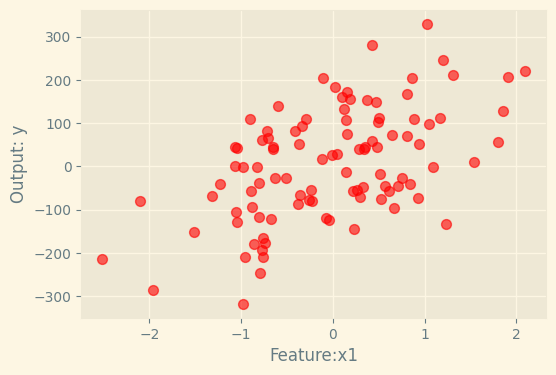

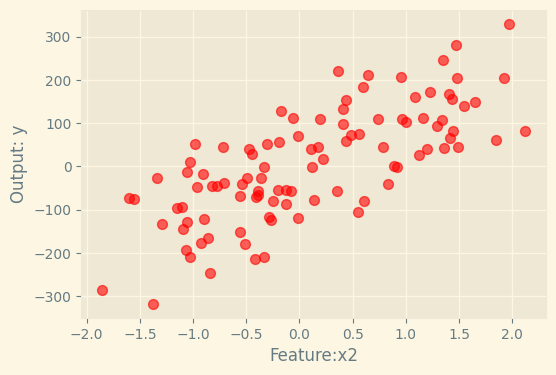

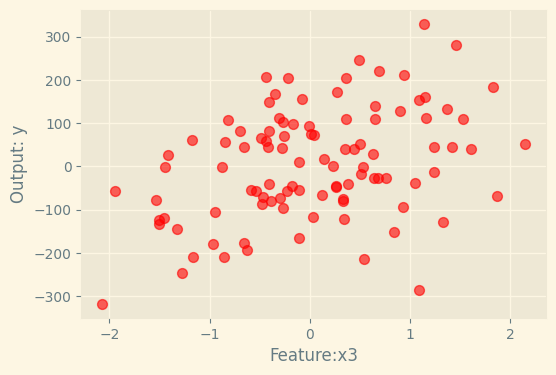

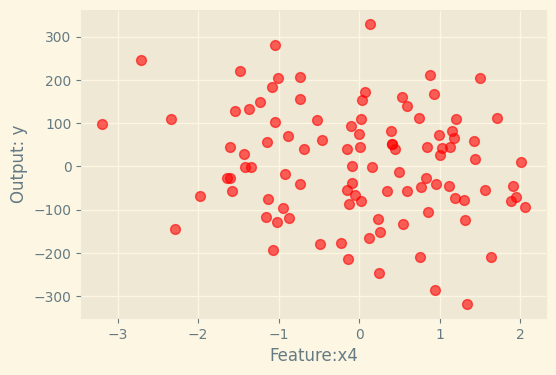

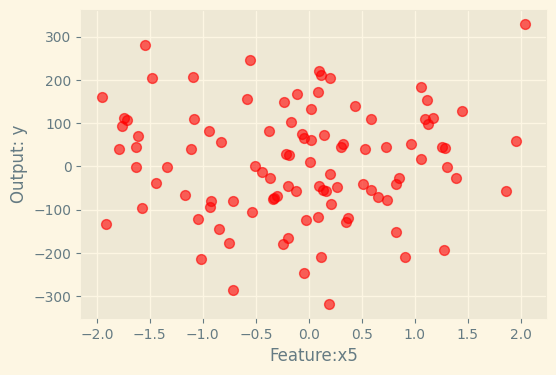

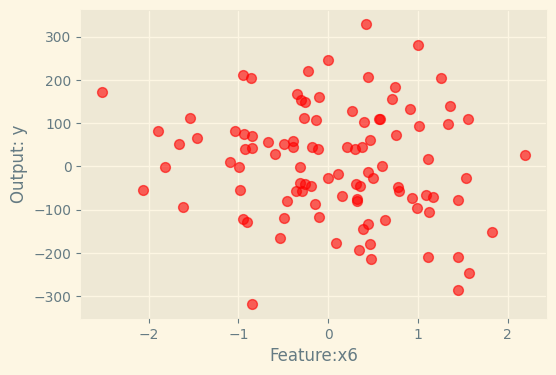

In [ ]:
# Visualizamos la relación entre cada característica artificial ('x1' a 'x6') y la variable objetivo 'y'.
# Se utiliza el estilo 'Solarize_Light2' para los gráficos.
with plt.style.context(('Solarize_Light2')):
  for i,col in enumerate(df.columns[ :- 1]):
    plt.figure(figsize=(6,4))
    plt.grid(True)
    plt.xlabel('Feature:'+col,fontsize=12)
    plt.ylabel('Output: y',fontsize=12)
    plt.scatter(df[col],df['y'],c='red',s=50,alpha=0.6)

In [ ]:
# Importamos el DecisionTreeRegressor, dividimos los datos en entrenamiento y prueba, y entrenamos un modelo de Árbol de Decisión.

from sklearn import tree
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=123
)

# Creación del modelo
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
# Se establece una profundidad máxima para evitar sobreajuste y un random_state para reproducibilidad.
tree_model.fit(x_train, y_train)


DecisionTreeRegressor(max_depth=5, random_state=10)

Mean square error (MSE): 7931.574768958281


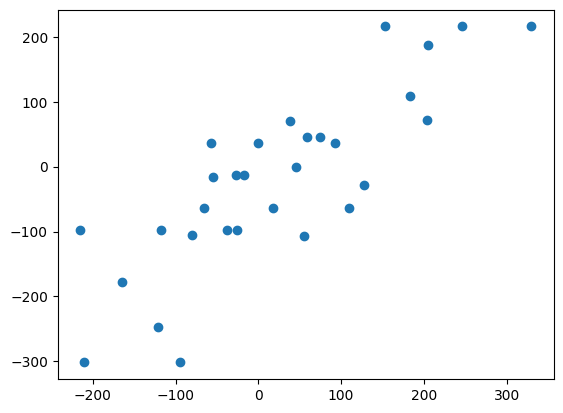

In [ ]:
# Realizamos predicciones sobre el conjunto de prueba usando el modelo de Árbol de Decisión y calculamos el Error Cuadrático Medio (MSE).
from sklearn import metrics

# Hacemos predicciones
test_pred = tree_model.predict(x_test)
plt.scatter(x=y_test, y=test_pred)  # real vs predicho
print("Mean square error (MSE):", metrics.mean_squared_error(y_test, test_pred))
# Error cuadrático medio

Importancia relativa de las características:  [0.26900246 0.53730467 0.11075698 0.03758107 0.01219288 0.03316193]


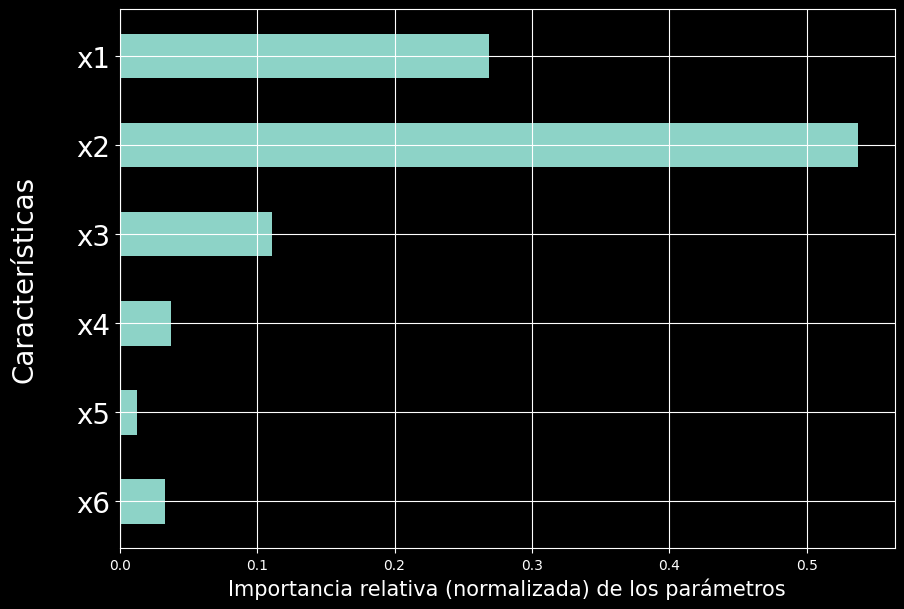

In [ ]:
# Imprimimos la importancia relativa de cada característica según el modelo de Árbol de Decisión y la visualizamos en un gráfico de barras horizontales.
print("Importancia relativa de las características: ", tree_model.feature_importances_)
with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features + 1, 1, -1), df.columns[:-1], fontsize=20)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(range(n_features + 1, 1, -1), width=tree_model.feature_importances_, height=0.5)

# MINIMOS CUADRADOS

In [ ]:
# Importamos la librería statsmodels.api para realizar un análisis de regresión mediante Mínimos Cuadrados Ordinarios (OLS).
import statsmodels.api as sm

In [ ]:
# Añadimos una constante a las variables predictoras (x) para el intercepto del modelo OLS.
# Luego, ajustamos el modelo OLS con la variable objetivo (y) y las predictoras (xs), y mostramos un resumen estadístico completo.
xs= sm.add_constant(x)
stat_model = sm.OLS(y,xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.976
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     628.6
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           5.97e-73
Time:                        21:29:57   Log-Likelihood:                -440.25
No. Observations:                 100   AIC:                             894.5
Df Residuals:                      93   BIC:                             912.7
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.8565      2.087     -1.848      0.0